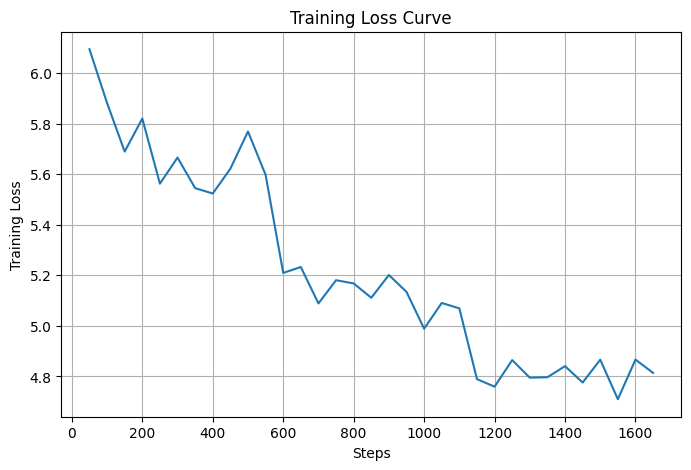

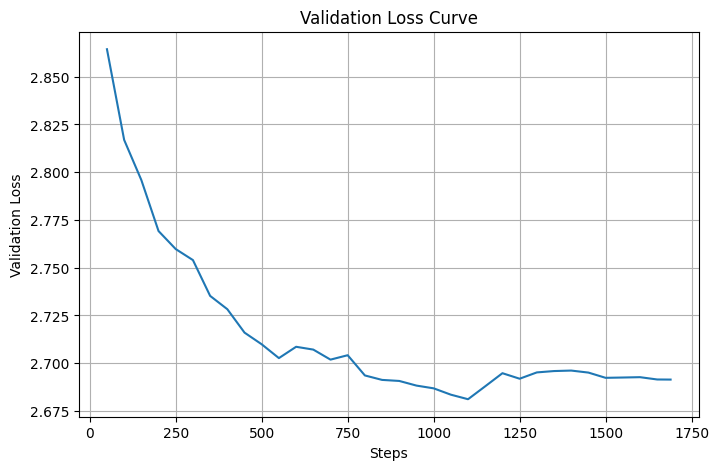

In [1]:
import json
import matplotlib.pyplot as plt

# path to trainer_state.json
path = "vit_caption_results/checkpoint-1689/trainer_state.json"

# load json
with open(path, "r") as f:
    data = json.load(f)

log_history = data["log_history"]

train_steps = []
train_loss = []

eval_steps = []
eval_loss = []
bleu_scores = []

for log in log_history:

    # training loss
    if "loss" in log:
        train_steps.append(log["step"])
        train_loss.append(log["loss"])

    # validation metrics
    if "eval_loss" in log:
        eval_steps.append(log["step"])
        eval_loss.append(log["eval_loss"])

    if "eval_bleu" in log:
        bleu_scores.append(log["eval_bleu"])

# Training Loss Curve
plt.figure(figsize=(8,5))
plt.plot(train_steps, train_loss)
plt.xlabel("Steps")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

# Validation Loss Curve
plt.figure(figsize=(8,5))
plt.plot(eval_steps, eval_loss)
plt.xlabel("Steps")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Curve")
plt.grid(True)
plt.show()

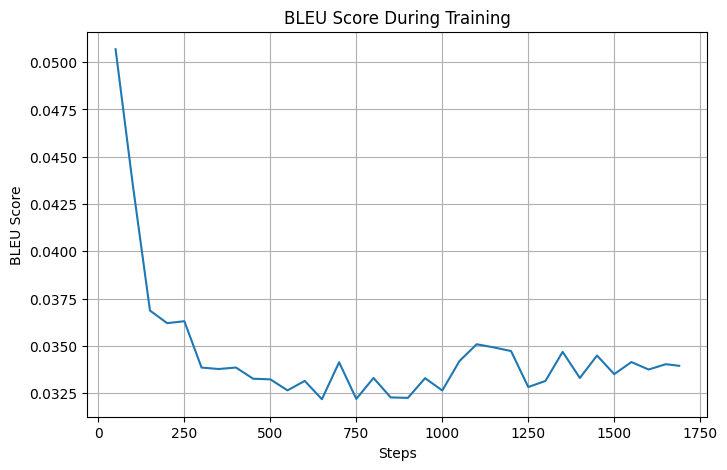

In [2]:
plt.figure(figsize=(8,5))
plt.plot(eval_steps[:len(bleu_scores)], bleu_scores)
plt.xlabel("Steps")
plt.ylabel("BLEU Score")
plt.title("BLEU Score During Training")
plt.grid(True)
plt.show()